In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print ("all good")

all good


In [27]:
Campaigns = pd.read_csv ('Campaigns Report.csv', skiprows= 3)
Ad_groups = pd.read_csv ('Ad Group Report.csv', skiprows= 3)
Keywords = pd.read_csv ('Keywords Report.csv', skiprows= 3)

print("=== CAMPAIGNS ===")
print(f"Shape: {campaigns.shape}")
print(Campaigns.head(3))
print("\n=== AD GROUPS ===")
print(f"Shape: {ad_groups.shape}")
print(Ad_groups.head(3))
print("\n=== KEYWORDS ===")
print(f"Shape: {keywords.shape}")
print(Keywords.head(3))

=== CAMPAIGNS ===
Shape: (119, 13)
   February 2015  2015  Search  DB | EUA - Search      33   1  0.00     0  \
0  February 2015  2015  Search        DbB: Brasil     342   1   1.0  0.00   
1     March 2015  2015  Search  DB | EUA - Search  11,083  27  18.0  0.00   
2     March 2015  2015  Search        DbB: Brasil  17,348  64  55.0  0.00   

     0.00%   0.1  3.03%  37.80%  EUR    0.77  
0  100.00%  0.00  0.29%  28.12%  EUR    1.84  
1   66.67%  0.00  0.24%  39.11%  EUR  141.54  
2   85.94%  0.00  0.37%  59.82%  EUR  148.57  

=== AD GROUPS ===
Shape: (186, 12)
   February 2015  2015  Search  DB | EUA - Search        Geral 29  0  0.00  \
0  February 2015  2015  Search  DB | EUA - Search          Spa  1  1   0.0   
1  February 2015  2015  Search  DB | EUA - Search     Location  3  0   0.0   
2  February 2015  2015  Search        DbB: Brasil  Localização  4  0   0.0   

  0.1    0.2 0.3    0.00%  52.83%  EUR  0.00.1  
0   0  0.00%   0  100.00%  14.29%  EUR    0.77  
1   0      0   0    0

In [36]:
campaign_cols = ['Month', 'Year', 'Campaign_type', 'Campaign', 'Impressions',
                 'Clicks', 'Conversions', 'Value_per_conv', 'All_conv_rate',
                 'All_conv_value', 'CTR', 'Search_impr_share', 'Currency', 'Cost']

adgroup_cols = ['Month', 'Year', 'Campaign_type', 'Campaign', 'Ad_group', 'Impressions',
                'Clicks', 'Conversions', 'Value_per_conv', 'All_conv_rate',
                'All_conv_value', 'CTR', 'Search_impr_share', 'Currency', 'Cost']

keyword_cols = ['Keyword', 'Match_type', 'Campaign', 'Ad_group', 'Year',
                'Quality_score', 'Month', 'Currency', 'Cost', 'Impressions',
                'Clicks', 'CTR', 'Conversions', 'All_conv_value', 
                'Value_per_conv', 'Search_impr_share']

campaigns = pd.read_csv('Campaigns Report.csv', skiprows=3, names=campaign_cols, header=0)
ad_groups = pd.read_csv('Ad Group Report.csv', skiprows=3, names=adgroup_cols, header=0)
keywords = pd.read_csv('Keywords Report.csv', skiprows=3, names=keyword_cols, header=0)

print("=== CAMPAIGNS ===")
print(f"Shape: {campaigns.shape}")
print(campaigns.head(2))
print("\n=== AD GROUPS ===")
print(f"Shape: {ad_groups.shape}")
print(ad_groups.head(2))
print("\n=== KEYWORDS ===")
print(f"Shape: {keywords.shape}")
print(keywords.head(2))

=== CAMPAIGNS ===
Shape: (628, 14)
           Month  Year Campaign_type           Campaign Impressions Clicks  \
0  February 2015  2015        Search        DbB: Brasil         342      1   
1     March 2015  2015        Search  DB | EUA - Search      11,083     27   

   Conversions Value_per_conv All_conv_rate All_conv_value    CTR  \
0          1.0           0.00       100.00%           0.00  0.29%   
1         18.0           0.00        66.67%           0.00  0.24%   

  Search_impr_share Currency    Cost  
0            28.12%      EUR    1.84  
1            39.11%      EUR  141.54  

=== AD GROUPS ===
Shape: (852, 15)
           Month  Year Campaign_type           Campaign  Ad_group Impressions  \
0  February 2015  2015        Search  DB | EUA - Search       Spa           1   
1  February 2015  2015        Search  DB | EUA - Search  Location           3   

  Clicks  Conversions Value_per_conv All_conv_rate All_conv_value      CTR  \
0      1          0.0              0         0.

In [37]:
import re

def clean_dataframe(df):
    
    # Drop currency column
    if 'Currency' in df.columns:
        df = df.drop(columns=['Currency'])
    
    # Remove total row (last row added by Google Ads)
    df = df[df['Campaign'].notna()]
    df = df[~df['Campaign'].str.lower().str.contains('total', na=False)]
    
    # Clean Impressions - remove commas and convert to int
    df['Impressions'] = df['Impressions'].astype(str).str.replace(',', '').str.strip()
    df['Impressions'] = pd.to_numeric(df['Impressions'], errors='coerce')
    
    # Clean CTR - remove % and convert to float
    df['CTR'] = df['CTR'].astype(str).str.replace('%', '').str.strip()
    df['CTR'] = pd.to_numeric(df['CTR'], errors='coerce')
    
    # Clean Search_impr_share - handle < 10% and remove %
    df['Search_impr_share'] = df['Search_impr_share'].astype(str).str.replace('%', '').str.strip()
    df['Search_impr_share'] = df['Search_impr_share'].replace('< 10', '5')
    df['Search_impr_share'] = pd.to_numeric(df['Search_impr_share'], errors='coerce')
    
    # Clean numeric columns
    for col in ['Cost', 'Conversions', 'Value_per_conv', 'All_conv_value']:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    
    return df

# Apply cleaning to all three datasets
campaigns = clean_dataframe(campaigns)
ad_groups = clean_dataframe(ad_groups)
keywords = clean_dataframe(keywords)

# Clean Quality_score in keywords specifically
keywords['Quality_score'] = keywords['Quality_score'].replace('--', np.nan)
keywords['Quality_score'] = pd.to_numeric(keywords['Quality_score'], errors='coerce')

# Confirm results
print("=== CAMPAIGNS ===")
print(campaigns.dtypes)
print(f"\nShape: {campaigns.shape}")
print("\n=== AD GROUPS ===")
print(ad_groups.dtypes)
print(f"\nShape: {ad_groups.shape}")
print("\n=== KEYWORDS ===")
print(keywords.dtypes)
print(f"\nShape: {keywords.shape}")

=== CAMPAIGNS ===
Month                 object
Year                   int64
Campaign_type         object
Campaign              object
Impressions            int64
Clicks                object
Conversions          float64
Value_per_conv       float64
All_conv_rate         object
All_conv_value       float64
CTR                  float64
Search_impr_share    float64
Cost                 float64
dtype: object

Shape: (628, 13)

=== AD GROUPS ===
Month                 object
Year                   int64
Campaign_type         object
Campaign              object
Ad_group              object
Impressions            int64
Clicks                object
Conversions          float64
Value_per_conv       float64
All_conv_rate         object
All_conv_value       float64
CTR                  float64
Search_impr_share    float64
Cost                 float64
dtype: object

Shape: (852, 14)

=== KEYWORDS ===
Keyword               object
Match_type            object
Campaign              object
Ad_group   

In [41]:
def clean_dataframe(df):
    # Drop currency column if present
    if 'Currency' in df.columns:
        df = df.drop(columns=['Currency'])
    
    # Remove total row
    if 'Campaign' in df.columns:
        df = df[df['Campaign'].notna()]
        df = df[~df['Campaign'].str.lower().str.contains('total', na=False)]
    
    # Clean Impressions
    df['Impressions'] = df['Impressions'].astype(str).str.replace(',', '').str.strip()
    df['Impressions'] = pd.to_numeric(df['Impressions'], errors='coerce')
    
    # Clean Clicks
    df['Clicks'] = df['Clicks'].astype(str).str.replace(',', '').str.strip()
    df['Clicks'] = pd.to_numeric(df['Clicks'], errors='coerce')
    
    # Clean CTR
    df['CTR'] = df['CTR'].astype(str).str.replace('%', '').str.strip()
    df['CTR'] = pd.to_numeric(df['CTR'], errors='coerce')
    
    # Clean Search_impr_share
    df['Search_impr_share'] = df['Search_impr_share'].astype(str).str.replace('%', '').str.strip()
    df['Search_impr_share'] = df['Search_impr_share'].replace('< 10', '5')
    df['Search_impr_share'] = pd.to_numeric(df['Search_impr_share'], errors='coerce')
    
    # Clean All_conv_rate if present
    if 'All_conv_rate' in df.columns:
        df['All_conv_rate'] = df['All_conv_rate'].astype(str).str.replace('%', '').str.strip()
        df['All_conv_rate'] = pd.to_numeric(df['All_conv_rate'], errors='coerce')
    
    # Clean numeric columns
    for col in ['Cost', 'Conversions', 'Value_per_conv', 'All_conv_value']:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    
    # Convert Month to datetime
    if 'Month' in df.columns:
        df['Month'] = pd.to_datetime(df['Month'], format='%B %Y')
    
    return df

# Apply to all three
campaigns = clean_dataframe(campaigns)
ad_groups = clean_dataframe(ad_groups)
keywords = clean_dataframe(keywords)

# Clean Quality_score in keywords
keywords['Quality_score'] = keywords['Quality_score'].replace('--', np.nan)
keywords['Quality_score'] = pd.to_numeric(keywords['Quality_score'], errors='coerce')

# Confirm
print("=== CAMPAIGNS ===")
print(campaigns.dtypes)
print(f"\nNull values:\n{campaigns.isnull().sum()}")
print("\n=== KEYWORDS ===")
print(keywords.dtypes)
print(f"\nNull values:\n{keywords.isnull().sum()}")

=== CAMPAIGNS ===
Month                datetime64[ns]
Year                          int64
Campaign_type                object
Campaign                     object
Impressions                   int64
Clicks                        int64
Conversions                 float64
Value_per_conv              float64
All_conv_rate               float64
All_conv_value              float64
CTR                         float64
Search_impr_share           float64
Cost                        float64
dtype: object

Null values:
Month                  0
Year                   0
Campaign_type          0
Campaign               0
Impressions            0
Clicks                 0
Conversions            0
Value_per_conv        10
All_conv_rate          0
All_conv_value         4
CTR                    0
Search_impr_share    178
Cost                   0
dtype: int64

=== KEYWORDS ===
Keyword                      object
Match_type                   object
Campaign                     object
Ad_group              

In [44]:
campaigns.to_csv('campaigns_clean.csv', index=False)
ad_groups.to_csv('ad_groups_clean.csv', index=False)
keywords.to_csv('keywords_clean.csv', index=False)

print("Cleaned files saved successfully")

Cleaned files saved successfully


In [45]:
# Load clean files
campaigns = pd.read_csv('campaigns_clean.csv', parse_dates=['Month'])
ad_groups = pd.read_csv('ad_groups_clean.csv', parse_dates=['Month'])
keywords = pd.read_csv('keywords_clean.csv', parse_dates=['Month'])

# Overall yearly performance
yearly = campaigns.groupby('Year').agg(
    Total_cost=('Cost', 'sum'),
    Total_clicks=('Clicks', 'sum'),
    Total_impressions=('Impressions', 'sum'),
    Total_conversions=('Conversions', 'sum'),
    Total_revenue=('All_conv_value', 'sum')
).reset_index()

# Calculate derived metrics
yearly['ROAS'] = yearly['Total_revenue'] / yearly['Total_cost']
yearly['CPA'] = yearly['Total_cost'] / yearly['Total_conversions']
yearly['Conv_rate'] = yearly['Total_conversions'] / yearly['Total_clicks'] * 100

print(yearly.to_string())

   Year  Total_cost  Total_clicks  Total_impressions  Total_conversions  Total_revenue      ROAS         CPA  Conv_rate
0  2015      478.97           178              53710             137.00           0.00  0.000000    3.496131  76.966292
1  2020     4334.68          4708              48374              16.00          66.93  0.015441  270.917500   0.339847
2  2021     4314.35         32583             792988             134.00          42.66  0.009888   32.196642   0.411257
3  2022     8767.52         46408             745478             405.00          89.33  0.010189   21.648198   0.872694
4  2023    12523.82         38557             677669             302.00        4438.03  0.354367   41.469603   0.783256
5  2024    10655.15         47455            1289479              43.75        3598.57  0.337731  243.546286   0.092193
6  2025    16386.75         22902             725725             160.26       12898.75  0.787145  102.251030   0.699764
7  2026     4950.08          6647       

In [46]:
# Focus on reliable revenue period
recent = campaigns[campaigns['Year'].isin([2023, 2024, 2025])]

yearly_recent = recent.groupby('Year').agg(
    Total_cost=('Cost', 'sum'),
    Total_clicks=('Clicks', 'sum'),
    Total_impressions=('Impressions', 'sum'),
    Total_conversions=('Conversions', 'sum'),
    Total_revenue=('All_conv_value', 'sum')
).reset_index()

yearly_recent['ROAS'] = yearly_recent['Total_revenue'] / yearly_recent['Total_cost']
yearly_recent['CPA'] = yearly_recent['Total_cost'] / yearly_recent['Total_conversions']
yearly_recent['Conv_rate'] = yearly_recent['Total_conversions'] / yearly_recent['Total_clicks'] * 100

print(yearly_recent.to_string())

   Year  Total_cost  Total_clicks  Total_impressions  Total_conversions  Total_revenue      ROAS         CPA  Conv_rate
0  2023    12523.82         38557             677669             302.00        4438.03  0.354367   41.469603   0.783256
1  2024    10655.15         47455            1289479              43.75        3598.57  0.337731  243.546286   0.092193
2  2025    16386.75         22902             725725             160.26       12898.75  0.787145  102.251030   0.699764


In [47]:
# Performance by campaign type - 2023 to 2025
campaign_type = recent.groupby(['Year', 'Campaign_type']).agg(
    Total_cost=('Cost', 'sum'),
    Total_clicks=('Clicks', 'sum'),
    Total_impressions=('Impressions', 'sum'),
    Total_conversions=('Conversions', 'sum'),
    Total_revenue=('All_conv_value', 'sum')
).reset_index()

campaign_type['ROAS'] = campaign_type['Total_revenue'] / campaign_type['Total_cost']
campaign_type['CPA'] = campaign_type['Total_cost'] / campaign_type['Total_conversions']
campaign_type['Conv_rate'] = campaign_type['Total_conversions'] / campaign_type['Total_clicks'] * 100

print(campaign_type.to_string())

   Year    Campaign_type  Total_cost  Total_clicks  Total_impressions  Total_conversions  Total_revenue      ROAS          CPA  Conv_rate
0  2023       Demand Gen     3606.37         22888             543478               1.00          24.92  0.006910  3606.370000   0.004369
1  2023          Display        0.00             0                 81               0.00           0.00       NaN          NaN        NaN
2  2023           Search     8917.45         15669             134110             301.00        4413.11  0.494885    29.626080   1.920990
3  2024       Demand Gen     2220.76         40222            1248553               0.00           5.00  0.002251          inf   0.000000
4  2024  Performance Max       37.71           141               2402               0.00           0.00  0.000000          inf   0.000000
5  2024           Search     8396.68          7092              38524              43.75        3593.57  0.427975   191.924114   0.616892
6  2025       Demand Gen      176.

In [48]:
# Search campaigns only - 2023 to 2025
search_campaigns = recent[recent['Campaign_type'] == 'Search'].groupby(
    ['Year', 'Campaign']
).agg(
    Total_cost=('Cost', 'sum'),
    Total_clicks=('Clicks', 'sum'),
    Total_impressions=('Impressions', 'sum'),
    Total_conversions=('Conversions', 'sum'),
    Total_revenue=('All_conv_value', 'sum')
).reset_index()

search_campaigns['ROAS'] = search_campaigns['Total_revenue'] / search_campaigns['Total_cost']
search_campaigns['CPA'] = search_campaigns['Total_cost'] / search_campaigns['Total_conversions']
search_campaigns['Conv_rate'] = search_campaigns['Total_conversions'] / search_campaigns['Total_clicks'] * 100

# Sort by revenue descending
search_campaigns = search_campaigns.sort_values(['Year', 'Total_revenue'], ascending=[True, False])

print(search_campaigns.to_string())

    Year                                           Campaign  Total_cost  Total_clicks  Total_impressions  Total_conversions  Total_revenue       ROAS          CPA  Conv_rate
11  2023                                       Sales_USA_CA     1245.39           612               2449               3.00        1458.73   1.171304   415.130000   0.490196
9   2023                                          Sales_ESP      369.39           787               2433              24.00        1024.84   2.774412    15.391250   3.049555
10  2023                   Sales_UK_IE (EN Marca Liberdade)     1334.25          1125               3916               8.00         975.24   0.730927   166.781250   0.711111
7   2023                Sales FR_BE_CH (FR Marca Liberdade)      686.21          1299               5088               9.00         634.35   0.924425    76.245556   0.692841
8   2023                      Sales PT (PT Marca Liberdade)      805.36          4423              17844             256.00       

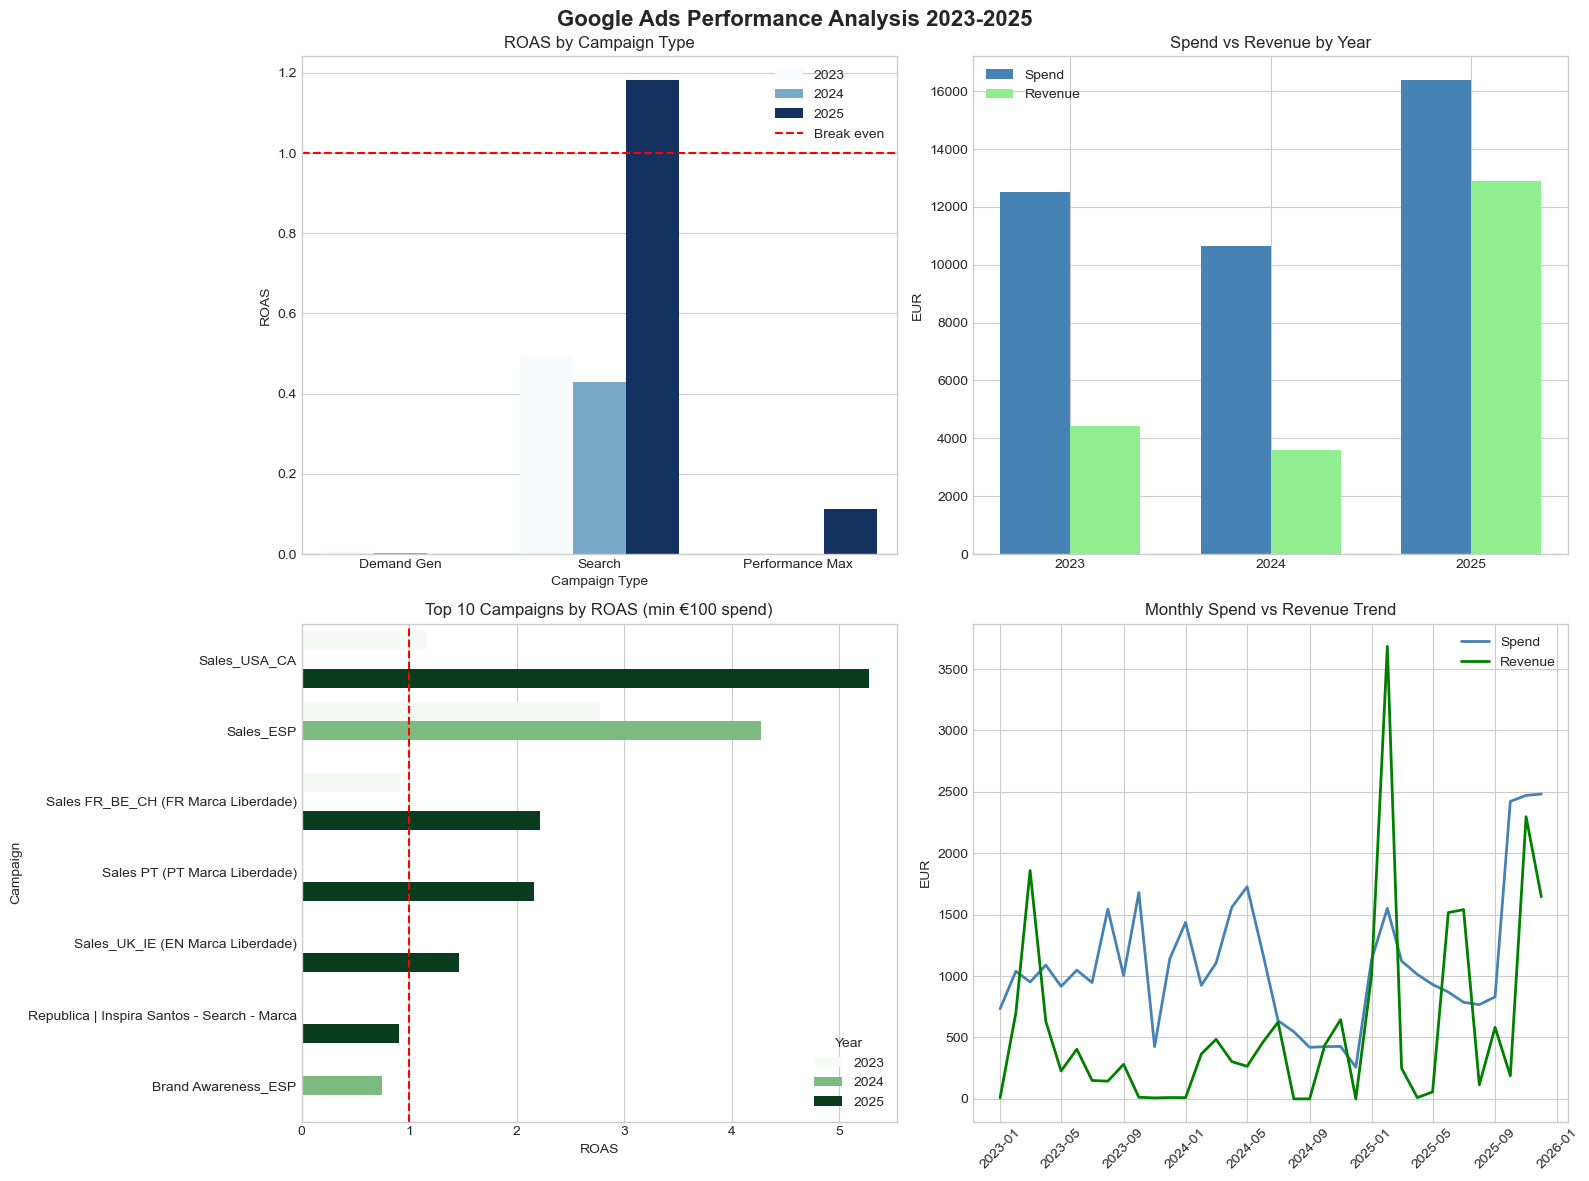

Chart saved


In [49]:
# Set style
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Google Ads Performance Analysis 2023-2025', fontsize=16, fontweight='bold')

# 1. ROAS by Campaign Type and Year
campaign_type_plot = campaign_type[campaign_type['Total_cost'] > 0].copy()
campaign_type_plot = campaign_type_plot[campaign_type_plot['ROAS'] != float('inf')]

sns.barplot(data=campaign_type_plot, x='Campaign_type', y='ROAS', 
            hue='Year', ax=axes[0,0], palette='Blues')
axes[0,0].set_title('ROAS by Campaign Type')
axes[0,0].set_xlabel('Campaign Type')
axes[0,0].set_ylabel('ROAS')
axes[0,0].axhline(y=1, color='red', linestyle='--', label='Break even')
axes[0,0].legend()

# 2. Spend vs Revenue by Year
yearly_recent_plot = yearly_recent.copy()
x = range(len(yearly_recent_plot))
width = 0.35
axes[0,1].bar([i - width/2 for i in x], yearly_recent_plot['Total_cost'], 
              width, label='Spend', color='steelblue')
axes[0,1].bar([i + width/2 for i in x], yearly_recent_plot['Total_revenue'], 
              width, label='Revenue', color='lightgreen')
axes[0,1].set_xticks(list(x))
axes[0,1].set_xticklabels(yearly_recent_plot['Year'])
axes[0,1].set_title('Spend vs Revenue by Year')
axes[0,1].set_ylabel('EUR')
axes[0,1].legend()

# 3. Top 10 campaigns by ROAS 2023-2025
top_campaigns = search_campaigns[
    (search_campaigns['Total_cost'] > 100) & 
    (search_campaigns['ROAS'] != float('inf')) &
    (search_campaigns['ROAS'] > 0)
].nlargest(10, 'ROAS')

sns.barplot(data=top_campaigns, x='ROAS', y='Campaign', 
            hue='Year', ax=axes[1,0], palette='Greens')
axes[1,0].set_title('Top 10 Campaigns by ROAS (min €100 spend)')
axes[1,0].set_xlabel('ROAS')
axes[1,0].axvline(x=1, color='red', linestyle='--')

# 4. Monthly spend and revenue trend 2023-2025
monthly = recent.groupby('Month').agg(
    Total_cost=('Cost', 'sum'),
    Total_revenue=('All_conv_value', 'sum')
).reset_index()

axes[1,1].plot(monthly['Month'], monthly['Total_cost'], 
               label='Spend', color='steelblue', linewidth=2)
axes[1,1].plot(monthly['Month'], monthly['Total_revenue'], 
               label='Revenue', color='green', linewidth=2)
axes[1,1].set_title('Monthly Spend vs Revenue Trend')
axes[1,1].set_ylabel('EUR')
axes[1,1].legend()
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('performance_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved")

In [50]:
# Load keywords clean file
keywords_recent = keywords[keywords['Year'].isin([2023, 2024, 2025])]

# Top keywords by revenue
top_keywords_revenue = keywords_recent.groupby(['Keyword', 'Match_type']).agg(
    Total_cost=('Cost', 'sum'),
    Total_clicks=('Clicks', 'sum'),
    Total_impressions=('Impressions', 'sum'),
    Total_conversions=('Conversions', 'sum'),
    Total_revenue=('All_conv_value', 'sum'),
    Avg_quality_score=('Quality_score', 'mean')
).reset_index()

top_keywords_revenue['ROAS'] = top_keywords_revenue['Total_revenue'] / top_keywords_revenue['Total_cost']
top_keywords_revenue['CPA'] = top_keywords_revenue['Total_cost'] / top_keywords_revenue['Total_conversions']
top_keywords_revenue['Conv_rate'] = top_keywords_revenue['Total_conversions'] / top_keywords_revenue['Total_clicks'] * 100

# Sort by revenue
top_keywords_revenue = top_keywords_revenue[top_keywords_revenue['Total_revenue'] > 0]
top_keywords_revenue = top_keywords_revenue.sort_values('Total_revenue', ascending=False)

print("=== TOP 20 KEYWORDS BY REVENUE ===")
print(top_keywords_revenue.head(20).to_string())

=== TOP 20 KEYWORDS BY REVENUE ===
                              Keyword   Match_type  Total_cost  Total_clicks  Total_impressions  Total_conversions  Total_revenue  Avg_quality_score       ROAS         CPA  Conv_rate
2    Inspira Liberdade Boutique Hotel  Exact match     2597.40          6686              32672             254.91       12593.65           9.107143   4.848560   10.189479   3.812593
141  inspira liberdade boutique hotel  Exact match     4332.74          2663              10530              31.34        7675.48           9.000000   1.771507  138.249521   1.176868
4             Inspira Liberdade Hotel  Exact match     1223.62          2126              10290              70.68        3765.32           9.107143   3.077197   17.312111   3.324553
140                 inspira liberdade  Exact match      575.97           361               1424              10.46        3275.47          10.000000   5.686876   55.064054   2.897507
1                   Inspira Liberdade  Exact match

C:\Users\dcard\AppData\Local\Temp\ipykernel_30008\4203127362.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10_revenue, x='Total_revenue', y='Keyword',
C:\Users\dcard\AppData\Local\Temp\ipykernel_30008\4203127362.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10_roas, x='ROAS', y='Keyword',


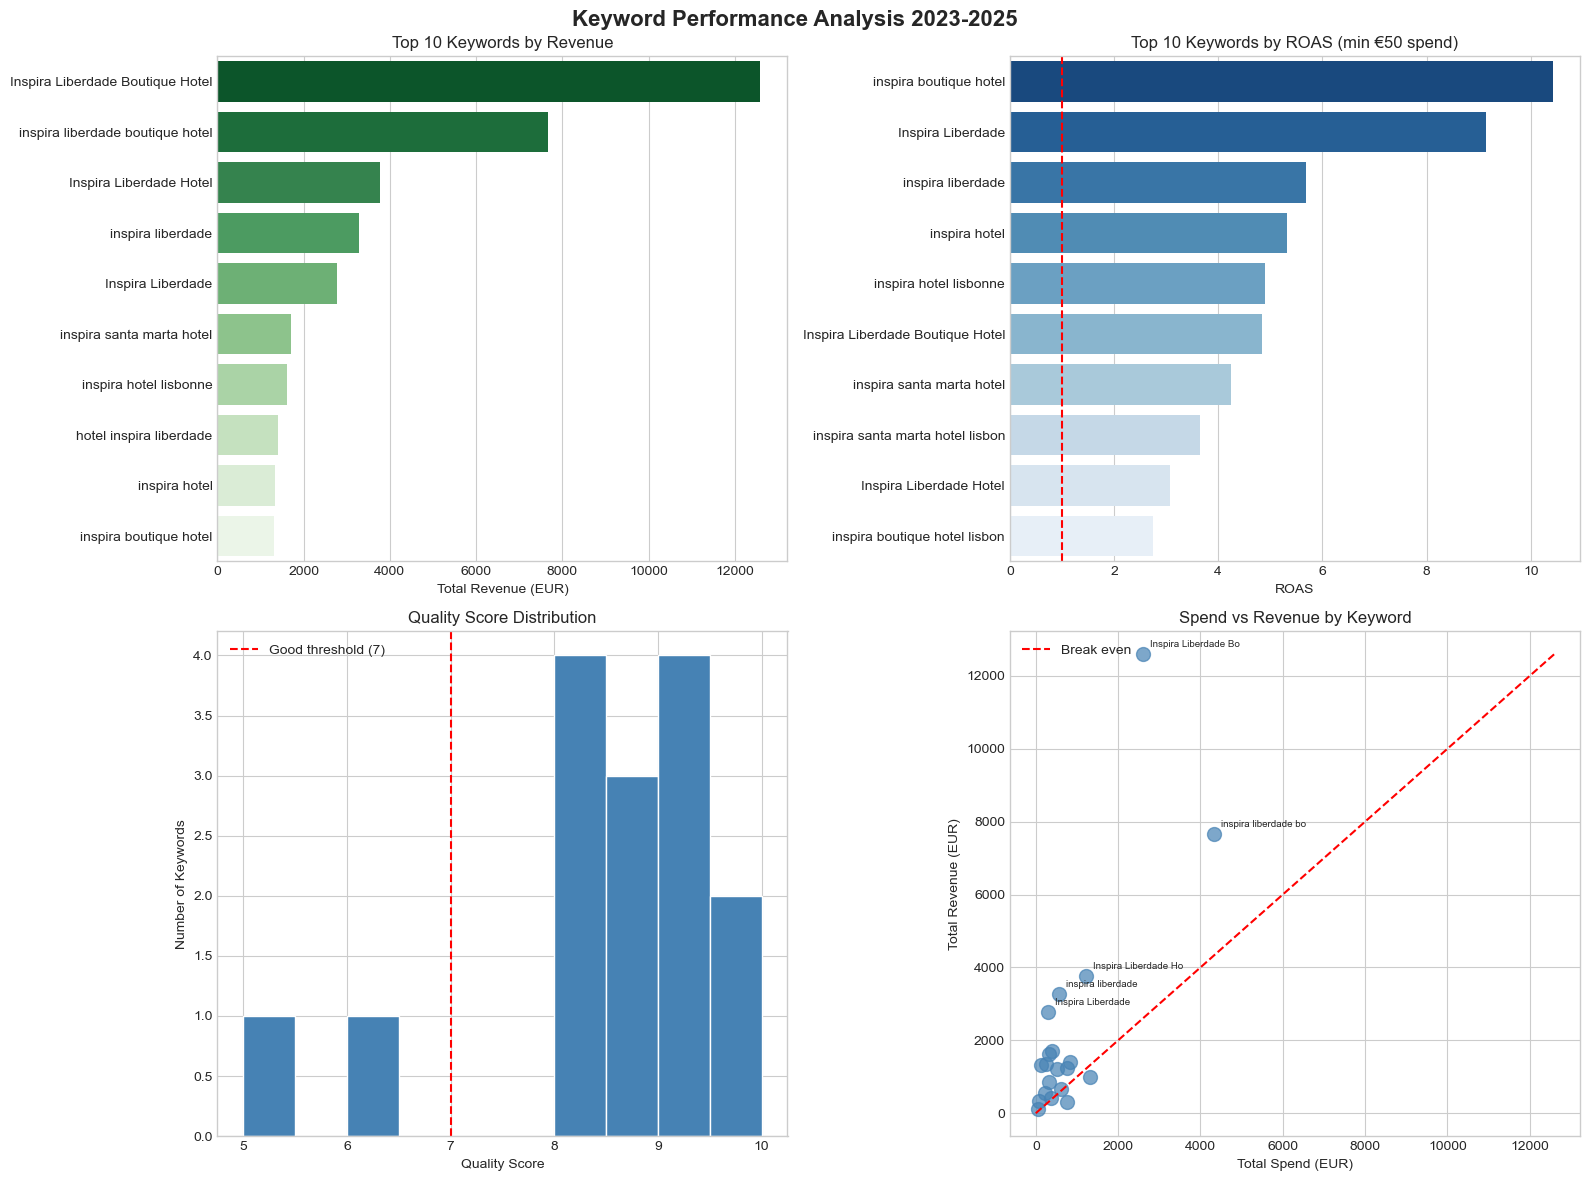

Chart saved


In [51]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Keyword Performance Analysis 2023-2025', fontsize=16, fontweight='bold')

# 1. Top 10 keywords by revenue
top10_revenue = top_keywords_revenue.head(10)
sns.barplot(data=top10_revenue, x='Total_revenue', y='Keyword', 
            ax=axes[0,0], palette='Greens_r')
axes[0,0].set_title('Top 10 Keywords by Revenue')
axes[0,0].set_xlabel('Total Revenue (EUR)')
axes[0,0].set_ylabel('')

# 2. Top 10 keywords by ROAS (min €50 spend, exclude inf)
top10_roas = top_keywords_revenue[
    (top_keywords_revenue['Total_cost'] > 50) &
    (top_keywords_revenue['ROAS'] != float('inf'))
].nlargest(10, 'ROAS')

sns.barplot(data=top10_roas, x='ROAS', y='Keyword', 
            ax=axes[0,1], palette='Blues_r')
axes[0,1].set_title('Top 10 Keywords by ROAS (min €50 spend)')
axes[0,1].set_xlabel('ROAS')
axes[0,1].set_ylabel('')
axes[0,1].axvline(x=1, color='red', linestyle='--')

# 3. Quality score distribution
qs_data = top_keywords_revenue[top_keywords_revenue['Avg_quality_score'].notna()]
axes[1,0].hist(qs_data['Avg_quality_score'], bins=10, color='steelblue', edgecolor='white')
axes[1,0].set_title('Quality Score Distribution')
axes[1,0].set_xlabel('Quality Score')
axes[1,0].set_ylabel('Number of Keywords')
axes[1,0].axvline(x=7, color='red', linestyle='--', label='Good threshold (7)')
axes[1,0].legend()

# 4. Cost vs Revenue scatter - top keywords
scatter_data = top_keywords_revenue[
    (top_keywords_revenue['Total_cost'] > 50) &
    (top_keywords_revenue['ROAS'] != float('inf'))
].head(20)

axes[1,1].scatter(scatter_data['Total_cost'], scatter_data['Total_revenue'], 
                  s=100, color='steelblue', alpha=0.7)

# Add break even line
max_val = max(scatter_data['Total_cost'].max(), scatter_data['Total_revenue'].max())
axes[1,1].plot([0, max_val], [0, max_val], 'r--', label='Break even')

# Label top points
for idx, row in scatter_data.head(5).iterrows():
    axes[1,1].annotate(row['Keyword'][:20], 
                       (row['Total_cost'], row['Total_revenue']),
                       textcoords="offset points", xytext=(5,5), fontsize=7)

axes[1,1].set_title('Spend vs Revenue by Keyword')
axes[1,1].set_xlabel('Total Spend (EUR)')
axes[1,1].set_ylabel('Total Revenue (EUR)')
axes[1,1].legend()

plt.tight_layout()
plt.savefig('keyword_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved")

In [52]:
import sqlite3

# Create database connection
conn = sqlite3.connect('google_ads_analysis.db')

# Write cleaned dataframes to SQL tables
campaigns.to_sql('campaigns', conn, if_exists='replace', index=False)
ad_groups.to_sql('ad_groups', conn, if_exists='replace', index=False)
keywords.to_sql('keywords', conn, if_exists='replace', index=False)

# Verify tables were created
cursor = conn.cursor()
cursor.execute("SELECT name FROM sqlite_master WHERE type='table'")
print("Tables created:", cursor.fetchall())

# Verify row counts
for table in ['campaigns', 'ad_groups', 'keywords']:
    cursor.execute(f"SELECT COUNT(*) FROM {table}")
    print(f"{table}: {cursor.fetchone()[0]} rows")

conn.close()
print("\nDatabase created successfully")

Tables created: [('campaigns',), ('ad_groups',), ('keywords',)]
campaigns: 628 rows
ad_groups: 852 rows
keywords: 3375 rows

Database created successfully


In [54]:
# Get all unique campaign names
unique_campaigns = pd.concat([
    campaigns['Campaign'],
    ad_groups['Campaign'],
    keywords['Campaign']
]).unique()

print(f"Total unique campaigns: {len(unique_campaigns)}")
print(unique_campaigns)

Total unique campaigns: 47
['DbB: Brasil' 'DB | EUA - Search' 'DB | Espanha - Search'
 'DB | Brasil - Search' 'DB | Brasil - Remarketing'
 'DB | Espanha - Remarketing' 'Sales_UK_IE (EN Marca Liberdade)'
 'Sales_USA_CA' 'Sales FR_BE_CH (FR Marca Liberdade)'
 'BA_CityBreak_UK_IE_DE_NL' 'Programa Dia dos Namorados'
 'Restaurante Open PT' 'Brand Awareness FR' 'Sales_DE_CH_BE_NL'
 'Brand Awareness - MICE PT' 'Brand_Awareness_PT' 'Brand Awareness_USA'
 'Brand_Discover_FR' 'Brand_Discover_ESP' 'Sales_ESP'
 'Brand_Discovery_DE_NL_CH_BE' 'BrandDiscovery_Display_ESP'
 'Brand Awareness_ESP' 'Brand_Discovery_Europe' 'BA_Discovery_PT'
 'Sales PT (PT Marca Liberdade)' 'Brand_Discover_USA' 'Brand_Discovery_UK'
 'Brand_Discovery_BR' 'Restaurante Open_ENG' 'BADC_Semana_Santa_ESP'
 'BAS_Passagem_Ano_PT' 'BAD_Passagem_Ano_PT' 'Remarketing ENG'
 'RMKTG_Display_ENG' 'Brand_Awareness_BR' 'Brand_Demand_Gen_USA'
 'BAS_Hotels_Lisbon_Europe_Green' 'BAD_DemandGen_Scandinavia'
 'PerformMax_ESP' 'BAS_Hotels_Lisbon

In [55]:
campaign_mapping = {
    'DbB: Brasil': 'Search_Brand_BR',
    'DB | EUA - Search': 'Search_Brand_USA',
    'DB | Espanha - Search': 'Search_Brand_ESP',
    'DB | Brasil - Search': 'Search_Brand_BR_2',
    'DB | Brasil - Remarketing': 'Remarketing_BR',
    'DB | Espanha - Remarketing': 'Remarketing_ESP',
    'Sales_UK_IE (EN Marca Liberdade)': 'Sales_UK_IE',
    'Sales_USA_CA': 'Sales_USA_CA',
    'Sales FR_BE_CH (FR Marca Liberdade)': 'Sales_FR_BE_CH',
    'BA_CityBreak_UK_IE_DE_NL': 'Brand_CityBreak_Europe',
    'Programa Dia dos Namorados': 'Seasonal_Valentines_PT',
    'Restaurante Open PT': 'Restaurant_PT',
    'Brand Awareness FR': 'Brand_Awareness_FR',
    'Sales_DE_CH_BE_NL': 'Sales_DE_CH_BE_NL',
    'Brand Awareness - MICE PT': 'Brand_MICE_PT',
    'Brand_Awareness_PT': 'Brand_Awareness_PT',
    'Brand Awareness_USA': 'Brand_Awareness_USA',
    'Brand_Discover_FR': 'Brand_Discovery_FR',
    'Brand_Discover_ESP': 'Brand_Discovery_ESP',
    'Sales_ESP': 'Sales_ESP',
    'Brand_Discovery_DE_NL_CH_BE': 'Brand_Discovery_DE_NL_CH_BE',
    'BrandDiscovery_Display_ESP': 'Brand_Discovery_Display_ESP',
    'Brand Awareness_ESP': 'Brand_Awareness_ESP',
    'Brand_Discovery_Europe': 'Brand_Discovery_Europe',
    'BA_Discovery_PT': 'Brand_Discovery_PT',
    'Sales PT (PT Marca Liberdade)': 'Sales_PT',
    'Brand_Discover_USA': 'Brand_Discovery_USA',
    'Brand_Discovery_UK': 'Brand_Discovery_UK',
    'Brand_Discovery_BR': 'Brand_Discovery_BR',
    'Restaurante Open_ENG': 'Restaurant_ENG',
    'BADC_Semana_Santa_ESP': 'Seasonal_Easter_ESP',
    'BAS_Passagem_Ano_PT': 'Seasonal_NewYear_PT',
    'BAD_Passagem_Ano_PT': 'Seasonal_NewYear_PT_2',
    'Remarketing ENG': 'Remarketing_ENG',
    'RMKTG_Display_ENG': 'Remarketing_Display_ENG',
    'Brand_Awareness_BR': 'Brand_Awareness_BR',
    'Brand_Demand_Gen_USA': 'DemandGen_USA',
    'BAS_Hotels_Lisbon_Europe_Green': 'Brand_Sustainability_Europe',
    'BAD_DemandGen_Scandinavia': 'DemandGen_Scandinavia',
    'PerformMax_ESP': 'PerformanceMax_ESP',
    'BAS_Hotels_Lisbon_Exclude Green': 'Brand_Hotels_Europe',
    'Republica | Inspira Santos - Search - Marca': 'Search_Brand_Hotel2',
    'Republica | Inspira Santos - Search - Localização': 'Search_Location_Hotel2',
    'Republica | Inspira Santos - Pmax - EN - United Kingdom': 'PMax_Hotel2_UK',
    'Republica | Inspira Santos - Pmax - EN - New York': 'PMax_Hotel2_USA',
    'Republica | Inspira Liberdade - Pmax - EN - United Kingdom': 'PMax_Hotel1_UK',
    'Republica | Inspira Liberdade - Pmax - EN - New York': 'PMax_Hotel1_USA'
}

# Apply mapping to all three dataframes
campaigns['Campaign'] = campaigns['Campaign'].replace(campaign_mapping)
ad_groups['Campaign'] = ad_groups['Campaign'].replace(campaign_mapping)
keywords['Campaign'] = keywords['Campaign'].replace(campaign_mapping)

# Also anonymize keywords that contain the brand name
keywords['Keyword'] = keywords['Keyword'].str.replace(
    'inspira', 'hotel_brand', case=False, regex=False)
keywords['Keyword'] = keywords['Keyword'].str.replace(
    'liberdade', 'property_1', case=False, regex=False)
keywords['Keyword'] = keywords['Keyword'].str.replace(
    'santa marta', 'property_2', case=False, regex=False)
keywords['Keyword'] = keywords['Keyword'].str.replace(
    'republica', 'property_3', case=False, regex=False)

# Verify
print("Sample campaigns after anonymization:")
print(campaigns['Campaign'].unique()[:10])
print("\nSample keywords after anonymization:")
print(keywords['Keyword'].head(10))

Sample campaigns after anonymization:
['Search_Brand_BR' 'Search_Brand_USA' 'Search_Brand_ESP'
 'Search_Brand_BR_2' 'Remarketing_BR' 'Remarketing_ESP' 'Sales_UK_IE'
 'Sales_USA_CA' 'Sales_FR_BE_CH' 'Brand_CityBreak_Europe']

Sample keywords after anonymization:
0             hotel in lisbon
1    hotel in lisbon portugal
2    hotel in lisbon portugal
3             hotel in lisbon
4             hotel in lisbon
5    hotel in lisbon portugal
6    hotel in lisbon portugal
7       hotel rooms in lisbon
8              booking lisbon
9       boutique hotel lisbon
Name: Keyword, dtype: object


In [56]:
# Save anonymized versions
campaigns.to_csv('campaigns_clean.csv', index=False)
ad_groups.to_csv('ad_groups_clean.csv', index=False)
keywords.to_csv('keywords_clean.csv', index=False)

print("Anonymized files saved")

Anonymized files saved
